#Meteostat

In [ ]:
!pip install meteostat -q

<img src= "https://www.meteo60.fr/satellites/animation-satellite-ir-france.gif" width="900">

In [ ]:
#https://dev.meteostat.net/api/stations/meta.html#response

In [ ]:
 # cities coordintes
 #https://www.latlong.net/category/cities-109-15-2.html

https://www.latlong.net/category/cities-109-15-2.html

In [22]:
#cities = {'city_name':[Latitude,Longitude]}
cities = {'Bologna':[44.498955,11.327591]}
cities.values()

list(cities.values())[0][0] #Latitude

44.498955

In [23]:
list(cities.keys())[0]

'Bologna'

In [24]:
# Import Meteostat library and dependencies
from datetime import datetime
from meteostat import Point, Station, daily, stations

# Set time period
start = datetime(2020, 1, 1)
end = datetime(2025, 5, 12)

cities = {'Bologna': [44.498955, 11.327591]}

# Find nearest weather station to the city coordinates
city_point = Point(list(cities.values())[0][0], list(cities.values())[0][1], 20)
nearby = stations.nearby(city_point, radius=50000, limit=1)
station_id = nearby.index[0]
print(f"Using station: {station_id} - {nearby.loc[station_id, 'name']}")

# Get daily data
data = daily(Station(station_id), start, end).fetch()
data

Using station: 16140 - Bologna / Borgo Panigale


,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2020-01-01,3.7,0.8,9.0,73,<NA>,<NA>,4.8,<NA>,1031.2,<NA>,<NA>
2020-01-02,2.9,-1.0,8.0,86,<NA>,<NA>,7.6,<NA>,1032.5,<NA>,<NA>
2020-01-03,5.1,1.0,11.0,77,<NA>,<NA>,6.9,<NA>,1027.4,<NA>,<NA>
2020-01-04,6.5,3.0,12.0,83,<NA>,<NA>,6.9,<NA>,1023.5,<NA>,<NA>
2020-01-05,5.0,0.0,11.0,78,<NA>,<NA>,7.7,<NA>,1027.5,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
2025-05-08,14.2,9.0,19.0,77,0.9,<NA>,7.7,<NA>,1010.4,<NA>,4
2025-05-09,15.3,10.8,20.0,78,2.7,<NA>,8.2,<NA>,1014.0,<NA>,5
2025-05-10,16.9,12.7,22.0,73,2.6,<NA>,5.8,<NA>,1017.8,<NA>,4


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1959 entries, 2020-01-01 to 2025-05-12
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    1959 non-null   Float64
 1   tmin    1959 non-null   Float64
 2   tmax    1959 non-null   Float64
 3   rhum    1959 non-null   UInt8  
 4   prcp    1056 non-null   Float64
 5   snwd    0 non-null      UInt16 
 6   wspd    1959 non-null   Float64
 7   wpgt    0 non-null      Float64
 8   pres    1959 non-null   Float64
 9   tsun    386 non-null    UInt16 
 10  cldc    1017 non-null   UInt8  
dtypes: Float64(7), UInt16(2), UInt8(2)
memory usage: 155.0 KB


In [26]:
#Iteration Pandas

for city in cities.items():
    print(city)

('Bologna', [44.498955, 11.327591])


In [27]:
for key, value in cities.items():
    print(key, '->', value)
    print(value[0])

Bologna -> [44.498955, 11.327591]
44.498955


## Multiples

In [28]:
# Import Meteostat library and dependencies
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Point, Station, daily, stations
import pandas as pd

# Set time period
start = datetime(2020, 1, 1)
end = datetime(2023, 2, 9)

cities = {'Bologna': [44.498955, 11.327591],
          'Ravenna': [44.418362, 12.203529]}

###############################################################

data = pd.DataFrame()

for key, value in cities.items():
    print(key, '->', value)
    city_point = Point(value[0], value[1], 20)
    nearby = stations.nearby(city_point, radius=50000, limit=1)
    station_id = nearby.index[0]
    print(f"  → stazione: {station_id} - {nearby.loc[station_id, 'name']}")

    data1 = daily(Station(station_id), start, end).fetch()
    data1['city'] = key
    data = pd.concat([data, data1], ignore_index=False)


data.to_csv('test.csv')
print('Done!')
data

Bologna -> [44.498955, 11.327591]
  → stazione: 16140 - Bologna / Borgo Panigale
Ravenna -> [44.418362, 12.203529]
  → stazione: 16146 - Punta Marina
Done!


,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc,city
time,,,,,,,,,,,,
2020-01-01,3.7,0.8,9.0,73,<NA>,<NA>,4.8,<NA>,1031.2,<NA>,<NA>,Bologna
2020-01-02,2.9,-1.0,8.0,86,<NA>,<NA>,7.6,<NA>,1032.5,<NA>,<NA>,Bologna
2020-01-03,5.1,1.0,11.0,77,<NA>,<NA>,6.9,<NA>,1027.4,<NA>,<NA>,Bologna
2020-01-04,6.5,3.0,12.0,83,<NA>,<NA>,6.9,<NA>,1023.5,<NA>,<NA>,Bologna
2020-01-05,5.0,0.0,11.0,78,<NA>,<NA>,7.7,<NA>,1027.5,<NA>,<NA>,Bologna
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-05,7.4,5.7,9.2,59,0.0,<NA>,22.2,<NA>,1031.9,<NA>,3,Ravenna
2023-02-06,5.2,3.1,7.9,53,0.0,<NA>,19.1,<NA>,1034.6,<NA>,2,Ravenna
2023-02-07,4.8,1.4,7.4,53,0.0,<NA>,11.2,<NA>,1036.2,<NA>,1,Ravenna


In [29]:
data.groupby('city').count()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
city,,,,,,,,,,,
Bologna,1136,1136,1136,1136,258,0,1136,0,1136,0,194
Ravenna,1136,1136,1136,1136,258,0,1136,0,1136,0,184


In [30]:
df = data[data['city']=='Bologna']

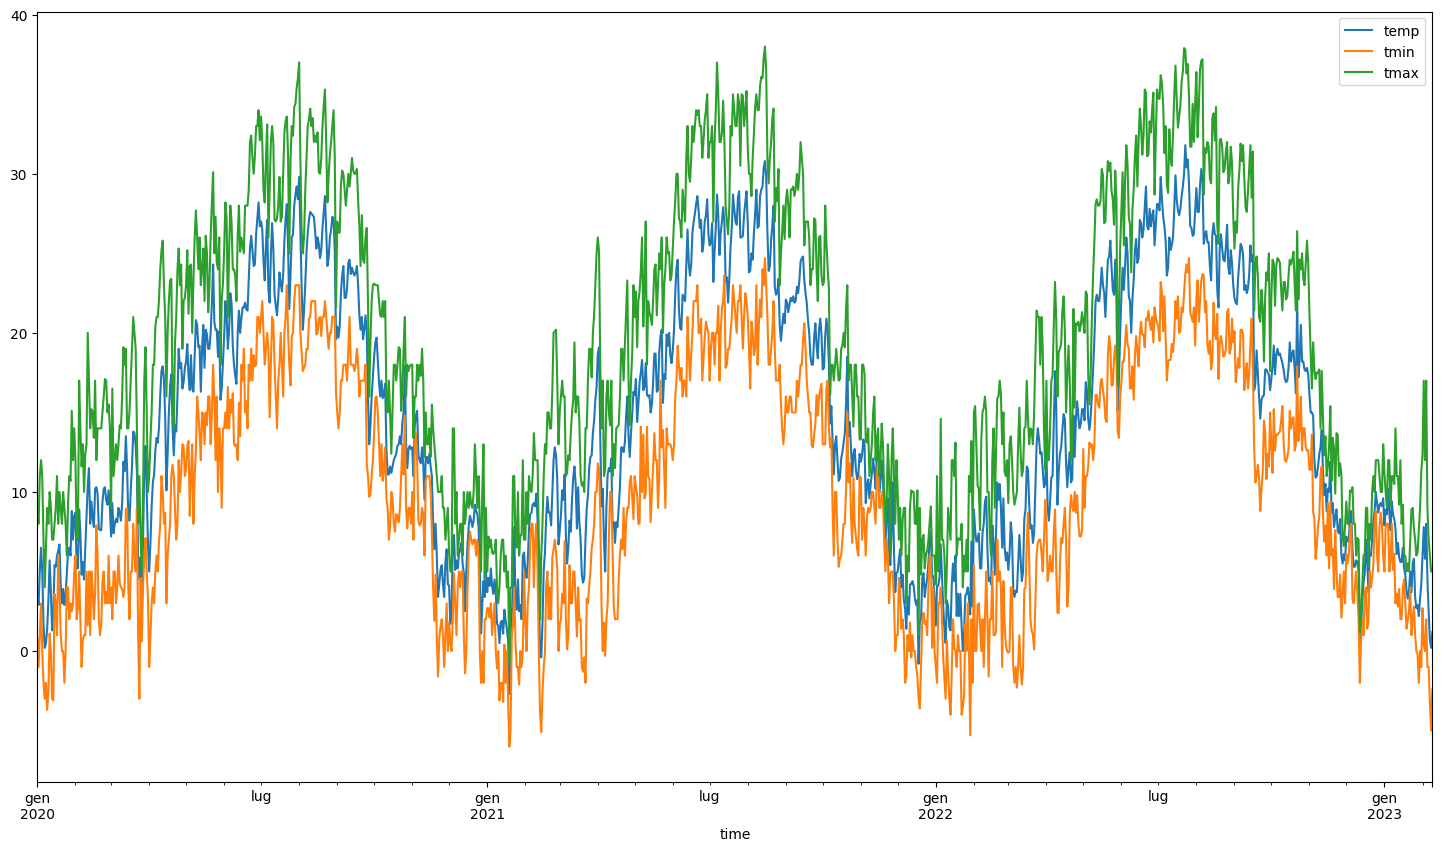

In [31]:
# Plot line chart including average, minimum and maximum temperature
# In meteostat v2: 'tavg' -> 'temp'
df.plot(y=['temp', 'tmin', 'tmax'], figsize=(18, 10))
plt.show()

In [32]:
df

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc,city
time,,,,,,,,,,,,
2020-01-01,3.7,0.8,9.0,73,<NA>,<NA>,4.8,<NA>,1031.2,<NA>,<NA>,Bologna
2020-01-02,2.9,-1.0,8.0,86,<NA>,<NA>,7.6,<NA>,1032.5,<NA>,<NA>,Bologna
2020-01-03,5.1,1.0,11.0,77,<NA>,<NA>,6.9,<NA>,1027.4,<NA>,<NA>,Bologna
2020-01-04,6.5,3.0,12.0,83,<NA>,<NA>,6.9,<NA>,1023.5,<NA>,<NA>,Bologna
2020-01-05,5.0,0.0,11.0,78,<NA>,<NA>,7.7,<NA>,1027.5,<NA>,<NA>,Bologna
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-05,4.5,-1.0,9.0,67,0.0,<NA>,12.9,<NA>,1031.2,<NA>,3,Bologna
2023-02-06,2.5,-1.0,7.0,67,0.0,<NA>,8.7,<NA>,1034.2,<NA>,3,Bologna
2023-02-07,0.7,-3.2,6.0,66,0.0,<NA>,6.9,<NA>,1036.6,<NA>,2,Bologna


In [33]:
### ZOOM

import plotly.graph_objects as go
fig = go.Figure()

# Average temperature
fig.add_trace(go.Scatter(x=df.index,
                         y=df['temp'],
                         mode="lines",
                         name="Avg",
                         line_color='#0000FF',
                         ))

# Max temperature
fig.add_trace(go.Scatter(x=df.index,
                         y=df['tmax'],
                         mode="lines",
                         name="Max",
                         line_color='#ff8c00',
                         ))

# adjust layout
fig.update_layout(title="Temperature Bologna",
                  xaxis_title="Date",
                  yaxis_title="Temperature (°C)",
                  width=1700,
                  height=700,
                  )

# zooming
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="2y", step="year", stepmode="backward"),
            dict(count=10, label="10y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

## Featurizing

In [34]:
# if we have time as a string column -->
# df['Mese'] = pd.to_datetime(df['Data']).dt.month
# df['Anno'] = pd.to_datetime(df['Data']).dt.year


In [35]:
import pandas as pd

url = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/monthly_csv.csv"
df1 = pd.read_csv( url,
                 index_col="Date",
                 parse_dates=['Date'],
                 )
df1

,Source,Mean
Date,,
2016-12-06,GCAG,0.7895
2016-12-06,GISTEMP,0.8100
2016-11-06,GCAG,0.7504
2016-11-06,GISTEMP,0.9300
2016-10-06,GCAG,0.7292
...,...,...
1880-03-06,GISTEMP,-0.1800
1880-02-06,GCAG,-0.1229
1880-02-06,GISTEMP,-0.2100


In [36]:
df1['year'] = pd.DatetimeIndex(df1.index).year
df1['month'] = pd.DatetimeIndex(df1.index).month
df1['day'] = pd.DatetimeIndex(df1.index).day

df1

,Source,Mean,year,month,day
Date,,,,,
2016-12-06,GCAG,0.7895,2016,12,6
2016-12-06,GISTEMP,0.8100,2016,12,6
2016-11-06,GCAG,0.7504,2016,11,6
2016-11-06,GISTEMP,0.9300,2016,11,6
2016-10-06,GCAG,0.7292,2016,10,6
...,...,...,...,...,...
1880-03-06,GISTEMP,-0.1800,1880,3,6
1880-02-06,GCAG,-0.1229,1880,2,6
1880-02-06,GISTEMP,-0.2100,1880,2,6


In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3288 entries, 2016-12-06 to 1880-01-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Source  3288 non-null   object 
 1   Mean    3288 non-null   float64
 2   year    3288 non-null   int32  
 3   month   3288 non-null   int32  
 4   day     3288 non-null   int32  
dtypes: float64(1), int32(3), object(1)
memory usage: 115.6+ KB


In [38]:
import altair as alt

alt.Chart(df1).mark_rect().encode(
    x= 'year:O' ,
    y= 'month:O' ,
    color=alt.Color( 'Mean:Q' , scale=alt.Scale( range =['blue','green', 'yellow','orange','red']))
).properties(width= 1600,height=550)

c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\altair\utils\core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.Chart(...)

In [39]:
alt.Chart(df1).mark_boxplot().encode(
    x='month',
    y='Mean'
).properties(width= 1000,height=550)

c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\altair\utils\core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.Chart(...)

In [40]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May','Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',]

charts =alt.hconcat(spacing=0)
for i in range(1,13):
    if i == 1:
        axis = alt.Axis(grid=False)
    else:
        axis = None
    chart = alt.Chart(df1).mark_line().encode(
        x=alt.X('year:O', title=months[i-1]),
        y=alt.Y('Mean', axis=axis)
    ).transform_filter(
        alt.FieldEqualPredicate(field='month', equal=i)
    ).properties(
        width=300,
        height=550
    )
    charts |= chart

charts

c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\altair\utils\core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.HConcatChart(...)